### SECTION A

Plot 1 - Target Distribution: the dataset is imbalanced having more 'answeable' data, meaning the agent can more often than not answer requests

Plot 2 - Live vs. Non-Live: we see 64% are live tasks of the whole, this suggest that our moder will be heavily influenced by static data.

Plot 3 - Task Domain: we can see that our top domain is 'other' which is practically a mixture of catagories which the data-set didnt name. we wont be discarding this catagory but we will not be referencing it, and starting our count at 'trave' which is the second most common catagory

Plot 4 - Task Complexity: we can see that at the low complexity there are more cant answers than in the high and medium, whiv are faily similar
Plot 5 - Aspect Coverage Ratio: on the left side we have the squished box at 0.0, meaning that for the vast majority, the model doesnt refuse, we also have a few outliers which means this is not 100% proof. on the other side of 'can answer' we see the box is covering everything from 0.0-1.0, this tells us that the aspect_covrage_ratio is not required for a task to be answerable

C:\Users\User\AppData\Local\Temp\ipykernel_13732\3618090954.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='can_answer', palette='viridis')


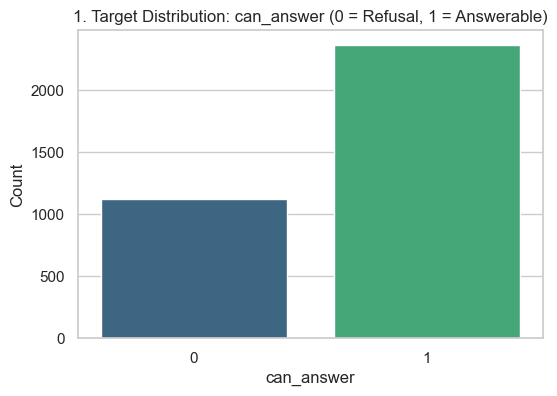

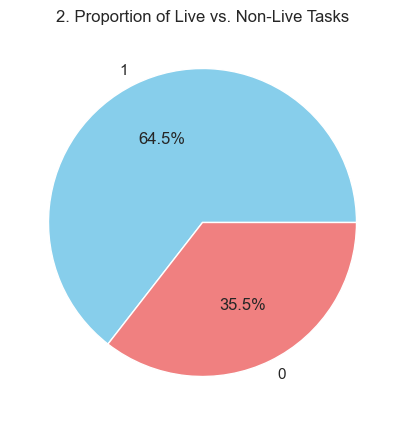

C:\Users\User\AppData\Local\Temp\ipykernel_13732\3618090954.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='task_domain', order=df['task_domain'].value_counts().index, palette='magma')


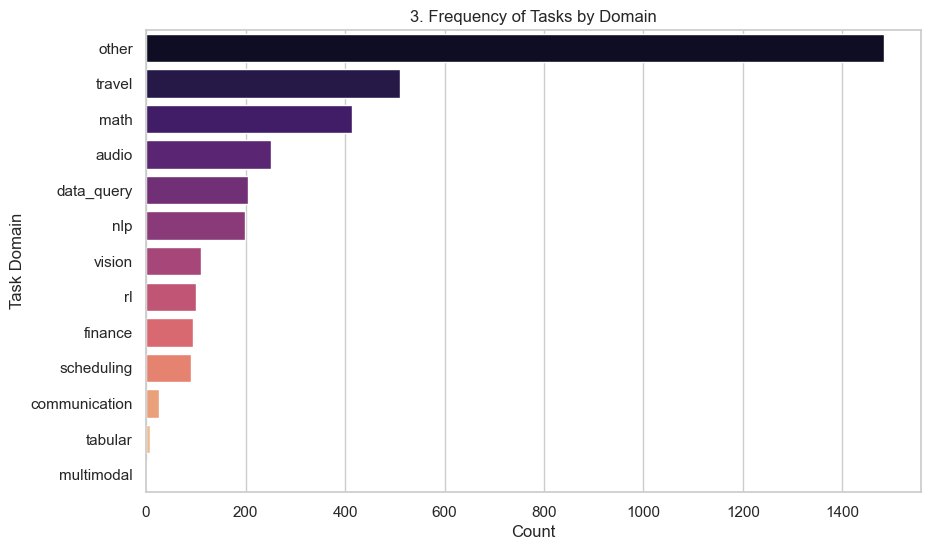

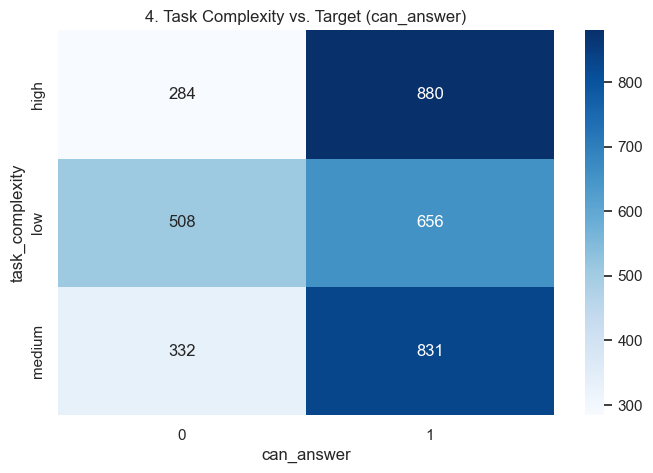

C:\Users\User\AppData\Local\Temp\ipykernel_13732\3618090954.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='can_answer', y='aspect_coverage_ratio', palette='Set2')


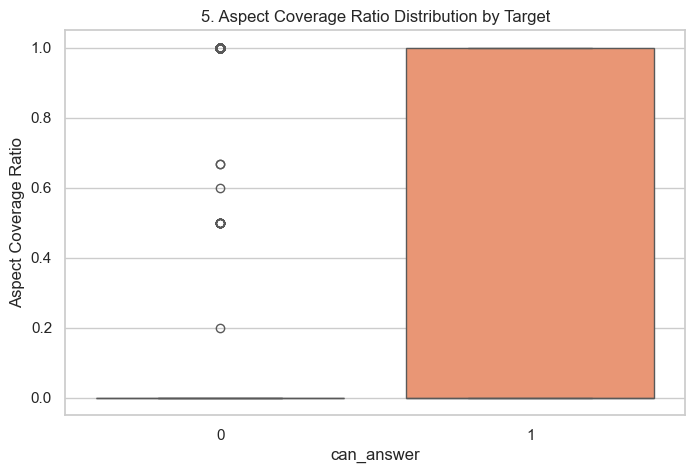

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the uploaded dataset
df = pd.read_csv('agent_tool_tasks.csv')

# Set visual style for consistency
sns.set_theme(style="whitegrid")

# --- Plot 1: Target Distribution (can_answer) ---
# Plot Type: Bar Plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='can_answer', palette='viridis')
plt.title('1. Target Distribution: can_answer (0 = Refusal, 1 = Answerable)')
plt.xlabel('can_answer')
plt.ylabel('Count')
plt.show()

# --- Plot 2: Live vs. Non-Live Tasks (is_live_benchmark) ---
# Plot Type: Pie Chart
plt.figure(figsize=(5, 5))
live_counts = df['is_live_benchmark'].value_counts()
plt.pie(live_counts, labels=live_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
plt.title('2. Proportion of Live vs. Non-Live Tasks')
plt.show()

# --- Plot 3: Task Domain ---
# Plot Type: Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='task_domain', order=df['task_domain'].value_counts().index, palette='magma')
plt.title('3. Frequency of Tasks by Domain')
plt.xlabel('Count')
plt.ylabel('Task Domain')
plt.show()

# --- Plot 4: Task Complexity ---
# Plot Type: Heatmap (Crosstab Table)
plt.figure(figsize=(8, 5))
complexity_crosstab = pd.crosstab(df['task_complexity'], df['can_answer'])
sns.heatmap(complexity_crosstab, annot=True, fmt='d', cmap='Blues')
plt.title('4. Task Complexity vs. Target (can_answer)')
plt.show()

# --- Plot 5: Query/Tool Matching (aspect_coverage_ratio) ---
# Plot Type: Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='can_answer', y='aspect_coverage_ratio', palette='Set2')
plt.title('5. Aspect Coverage Ratio Distribution by Target')
plt.xlabel('can_answer')
plt.ylabel('Aspect Coverage Ratio')
plt.show()

### SECTION B

#### part 1

In [5]:
import numpy as np
import pandas as pd

# 1. required_params_ratio
df['required_params_ratio'] = np.where(
    df['total_params'] == 0, 
    0, 
    df['total_required_params'] / df['total_params']
)

# 2. avg_params_per_tool
df['avg_params_per_tool'] = np.where(
    df['num_available_tools'] == 0, 
    0, 
    df['total_params'] / df['num_available_tools']
)

# 3. query_avg_word_length
def calc_avg_word_length(text):
    if pd.isna(text): 
        return 0
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df['query_avg_word_length'] = df['query'].apply(calc_avg_word_length)

# 4. query_mentions_number
df['query_mentions_number'] = df['query'].astype(str).str.contains(r'\d', regex=True).astype(int)

# 5. tool_name_diversity
def count_unique_prefixes(tools_str):
    if pd.isna(tools_str) or str(tools_str).strip() == '':
        return 0
    
    tools = str(tools_str).split('|')
    prefixes = set()
    
    for tool in tools:
        tool = tool.strip()
        if tool:  
            prefix = tool.split('.')[0]
            prefixes.add(prefix)
            
    return len(prefixes)

df['tool_name_diversity'] = df['tool_names'].apply(count_unique_prefixes)

#### part 2

##### Feature1 : query_word_count
    calculates the total number of words in the user's query.

    Very short queries often lack the necessary context or specific parameters required to successfully trigger a tool. Therefore, shorter queries are more likely to be refusal cases, making this a useful distinguishing feature.

###### Feature2: optional_params_count
    It measures the number of optional parameters a tool has by subtracting the strictly required parameters from the total parameters.

    It indicates tool flexibility. Tools with a higher number of optional parameters can handle a wider variety of queries and incomplete inputs, potentially increasing the chance of a successful tool call rather than a flat refusal.

##### Feature 3: aspect_match_ratio
    calculates the ratio of overlapping aspects out of all the relevant aspects evaluated between the query and the tool.

    It provides a normalized numerical metric of how well the query's intent aligns with the available tools. A higher ratio predicts an answerable case.

###### Feature 4: param_to_word_ratio
    calculates the ratio between the total parameters required by the tools and the total number of words provided in the user's query.

    It helps identify information gaps. If a tool requires a large number of parameters but the user provided a very short query, the agent likely does not have enough information to execute the tool, indicating a probable refusal case.

###### Feature 5: max_tool_name_similarity
    calculates a fuzzy string matching score (between 0.0 and 1.0) to determine how closely the available tool names resemble the words used in the user's query.

    Users often refer to tools explicitly but make formatting errors. A high similarity score strongly indicates that the user is intentionally asking for a specific tool, guiding the model to predict an answerable task with higher confidence, while remaining flexible to human typing patterns.

In [6]:
# Feature 1: Query Word Count
df['query_word_count'] = df['query'].astype(str).apply(lambda x: len(x.split()))

# Feature 2: Number of Optional Parameters
df['optional_params_count'] = df['total_params'] - df['total_required_params']

# Feature 3: Aspect Match Ratio (+1 in denominator to prevent division by zero)
df['aspect_match_ratio'] = df['aspect_overlap_count'] / (df['aspect_overlap_count'] + df['aspect_mismatch_count'] + 1)

# Feature 4: Parameter to Word Ratio (Requires feature 1 to be executed first)
df['param_to_word_ratio'] = df['total_params'] / (df['query_word_count'] + 1)


# Feature 5 (Upgraded): Max Tool Name Similarity Score
import difflib
def calc_max_tool_similarity(row):
    if pd.isna(row['tool_names']) or pd.isna(row['query']):
        return 0.0
    
    query = str(row['query']).lower()
    tools = str(row['tool_names']).lower().split('|')
    
    query_words = query.replace('_', ' ').replace('-', ' ').split()
    max_score = 0.0
    
    for tool in tools:
        tool = tool.strip()
        if not tool:
            continue
            
        tool_spaced = tool.replace('_', ' ').replace('-', ' ')
        tool_connected = tool.replace('_', '').replace('-', '')
        
        for i in range(len(query_words)):
            score1 = difflib.SequenceMatcher(None, tool_spaced, query_words[i]).ratio()
            max_score = max(max_score, score1)
            
            if i < len(query_words) - 1:
                pair_spaced = query_words[i] + ' ' + query_words[i+1]
                score2 = difflib.SequenceMatcher(None, tool_spaced, pair_spaced).ratio()
                max_score = max(max_score, score2)
                
                pair_connected = query_words[i] + query_words[i+1]
                score3 = difflib.SequenceMatcher(None, tool_connected, pair_connected).ratio()
                max_score = max(max_score, score3)
                
    return max_score

df['max_tool_name_similarity'] = df.apply(calc_max_tool_similarity, axis=1)

#### part 3

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np

forbidden_cols = ['task_uid', 'query', 'tool_names', 'can_answer']
X = df.drop(columns=forbidden_cols)
y = df['can_answer']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

cols_to_exclude = ['query_aspects', 'tool_aspects', 'total_required_params']
X_train = X_train.drop(columns=cols_to_exclude, errors='ignore')
X_val = X_val.drop(columns=cols_to_exclude, errors='ignore')
X_test = X_test.drop(columns=cols_to_exclude, errors='ignore')


numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

imputer = SimpleImputer(strategy='median')
imputer.fit(X_train[numeric_cols])

X_train[numeric_cols] = imputer.transform(X_train[numeric_cols])
X_val[numeric_cols] = imputer.transform(X_val[numeric_cols])
X_test[numeric_cols] = imputer.transform(X_test[numeric_cols])


categorical_cols = ['task_domain', 'task_complexity']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[categorical_cols])

def encode_df(X_data, enc, cat_cols):
    encoded_arr = enc.transform(X_data[cat_cols])
    encoded_df = pd.DataFrame(encoded_arr, columns=enc.get_feature_names_out(cat_cols), index=X_data.index)
    return pd.concat([X_data.drop(columns=cat_cols), encoded_df], axis=1)

X_train = encode_df(X_train, encoder, categorical_cols)
X_val = encode_df(X_val, encoder, categorical_cols)
X_test = encode_df(X_test, encoder, categorical_cols)

scaler = StandardScaler()
current_numeric = [c for c in X_train.columns if X_train[c].dtype in ['float64', 'int64']]

scaler.fit(X_train[current_numeric])

X_train[current_numeric] = scaler.transform(X_train[current_numeric])
X_val[current_numeric] = scaler.transform(X_val[current_numeric])
X_test[current_numeric] = scaler.transform(X_test[current_numeric])

### SECTION C

#### part 1 - Train / Validation / Test Split

In [10]:

# weve already done this on section B3
# Verifying the 80/10/10 split performed during Section B preprocessing
total_samples = len(X)

print(f"Total original dataset size: {total_samples} rows\n")
print(f"X_train shape: {X_train.shape}  | Percentage: {(len(X_train)/total_samples)*100:.1f}%")
print(f"X_val shape:   {X_val.shape}  | Percentage:  {(len(X_val)/total_samples)*100:.1f}%")
print(f"X_test shape:  {X_test.shape}  | Percentage:  {(len(X_test)/total_samples)*100:.1f}%")

Total original dataset size: 3491 rows

X_train shape: (2792, 49)  | Percentage: 80.0%
X_val shape:   (349, 49)  | Percentage:  10.0%
X_test shape:  (350, 49)  | Percentage:  10.0%


#### part 2 - Models

#### part 3 - Hyperparameter Tuning

##### C.3 Hyperparameter Tuning

For our three main supervised models, we are tuning at least two hyperparameters. To strictly avoid data leakage, we are using a custom tuning loop that trains the model on `X_train` and evaluates the combinations exclusively on `X_val` (the validation set).

In [11]:
import itertools
from sklearn.metrics import f1_score

# --- Custom Tuning Function using Validation Set ---
def tune_model(ModelClass, param_grid, X_train, y_train, X_val, y_val, is_tree=False):
    best_f1 = -1
    best_params = None
    best_model = None
    
    # Create all combinations of hyperparameters
    keys, values = zip(*param_grid.items())
    permutations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    for params in permutations:
        model = ModelClass(**params)
        if is_tree:
            model.set_params(random_state=42)
            
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        current_f1 = f1_score(y_val, y_val_pred, zero_division=0)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_params = params
            best_model = model
            
    return best_model, best_params

# --- 1. Tune KNN ---
knn_grid = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
best_knn, knn_params = tune_model(KNeighborsClassifier, knn_grid, X_train, y_train, X_val, y_val)

# --- 2. Tune AdaBoost ---
ada_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.1, 0.5, 1.0]}
best_ada, ada_params = tune_model(AdaBoostClassifier, ada_grid, X_train, y_train, X_val, y_val, is_tree=True)

# --- 3. Tune Random Forest ---
rf_grid = {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
best_rf, rf_params = tune_model(RandomForestClassifier, rf_grid, X_train, y_train, X_val, y_val, is_tree=True)

print(f"Best KNN Params: {knn_params}")
print(f"Best AdaBoost Params: {ada_params}")
print(f"Best RF Params: {rf_params}")

Best KNN Params: {'n_neighbors': 9, 'weights': 'distance'}
Best AdaBoost Params: {'n_estimators': 200, 'learning_rate': 0.1}
Best RF Params: {'n_estimators': 200, 'max_depth': None}


#### part 4 - Evaluation
Now that our best hyperparameters have been selected via the validation set, we will evaluate our tuned models (and our baseline) strictly on the unseen `X_test` dataset. This will be done only once to report our final metrics: Accuracy, Precision, Recall, and F1-score.

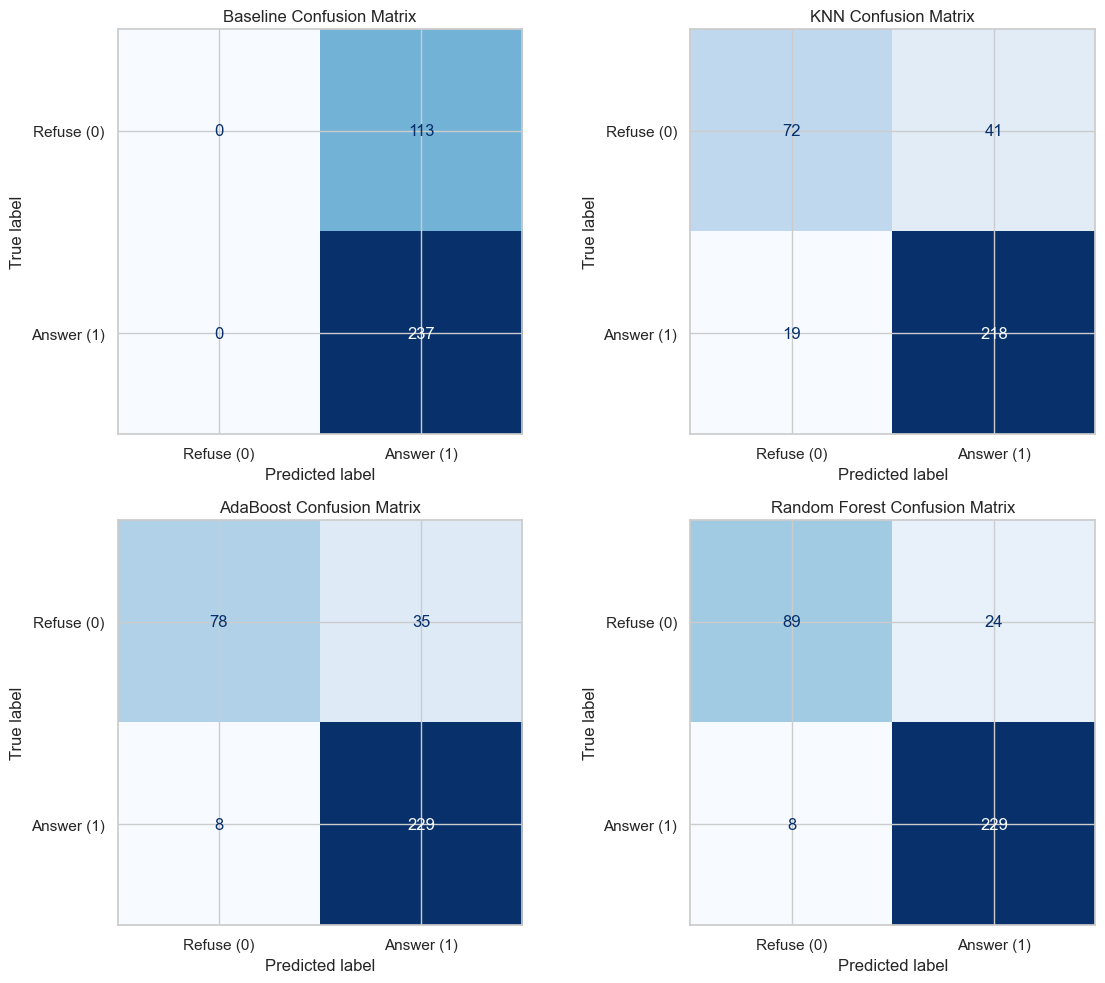

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline,0.677143,0.677143,1.000000,0.807496
1,KNN,0.828571,0.841699,0.919831,0.879032
2,AdaBoost,0.877143,0.867424,0.966245,0.914172
3,Random Forest,0.908571,0.905138,0.966245,0.934694


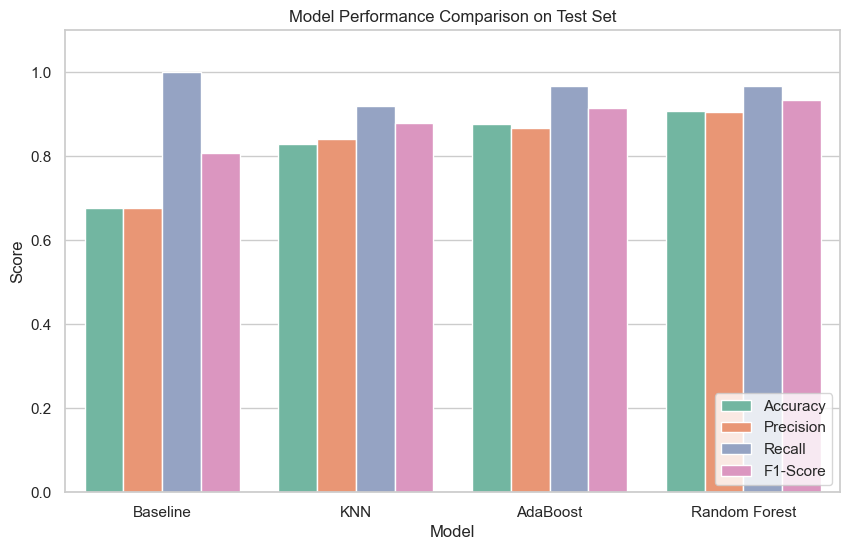

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

models = {
    'Baseline': baseline,
    'KNN': best_knn,
    'AdaBoost': best_ada,
    'Random Forest': best_rf
}

results = []
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    # Predict on test set ONLY ONCE
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Refuse (0)', 'Answer (1)'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

# Print Comparison DataFrame
results_df = pd.DataFrame(results)
display(results_df)

# Plot Comparison Bar Chart
plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Model Performance Comparison on Test Set')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()

### SECTION D